In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

users = pd.read_csv("../Data/users.csv")
products = pd.read_csv("../Data/products.csv")
orders = pd.read_csv("../Data/orders.csv")
order_items = pd.read_csv("../Data/order_items.csv")
payments = pd.read_csv("../Data/payments.csv")
categories = pd.read_csv("../Data/categories.csv")

In [30]:
# Revenue by category
df_cat = (
    order_items
    .merge(orders, on="order_id")
    .merge(products, on="product_id")
    .merge(categories, on="category_id")
)

df_cat = df_cat[df_cat["order_status"] == "DELIVERED"]
df_cat["revenue"] = df_cat["quantity"] * df_cat["item_price"]

revenue_by_category = (
    df_cat
    .groupby("category_name", as_index=False)
    .agg(total_revenue=("revenue", "sum"))
    .sort_values("total_revenue", ascending=False)
)

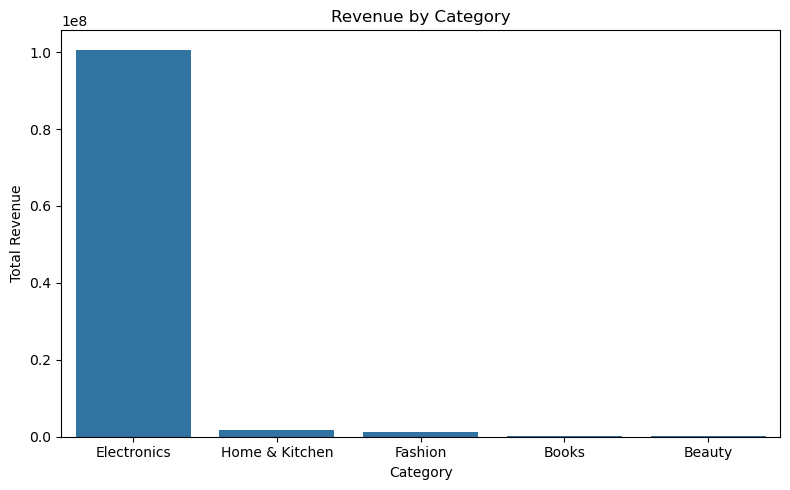

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=revenue_by_category,
    x="category_name",
    y="total_revenue"
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.tight_layout()

plt.savefig("../outputs/figures/revenue_by_category.png", dpi=300)
plt.show()


In [32]:
# average order value by city
df_city = (
    order_items
    .merge(orders, on="order_id", how="inner")
    .merge(users, on="user_id", how="inner")
)

df_city = df_city[df_city["order_status"] == "DELIVERED"]

df_city["revenue"] = df_city["quantity"] * df_city["item_price"]

In [33]:
df_city[["city", "order_id", "revenue"]].head()

,city,order_id,revenue
2,Delhi,2,22692.86
3,Delhi,3,23647.35
4,Delhi,3,55292.07
5,Delhi,3,58037.23
6,Mumbai,4,1493.28


In [34]:
city_perf = (
    df_city
    .groupby("city", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("revenue", "sum")
    )
)

city_perf["avg_order_value"] = (
    city_perf["total_revenue"] / city_perf["total_orders"]
)

city_perf = city_perf.sort_values(
    "avg_order_value", ascending=False
)

city_perf

,city,total_orders,total_revenue,avg_order_value
6,Surat,318,17850405.84,56133.351698
3,Mumbai,282,15690838.08,55641.269787
2,Delhi,255,14094022.26,55270.675529
1,Bangalore,230,12246775.05,53246.848043
0,Ahmedabad,291,15490961.32,53233.544055
4,Pune,308,15636246.64,50767.034545
5,Rajkot,267,13068564.46,48945.934307


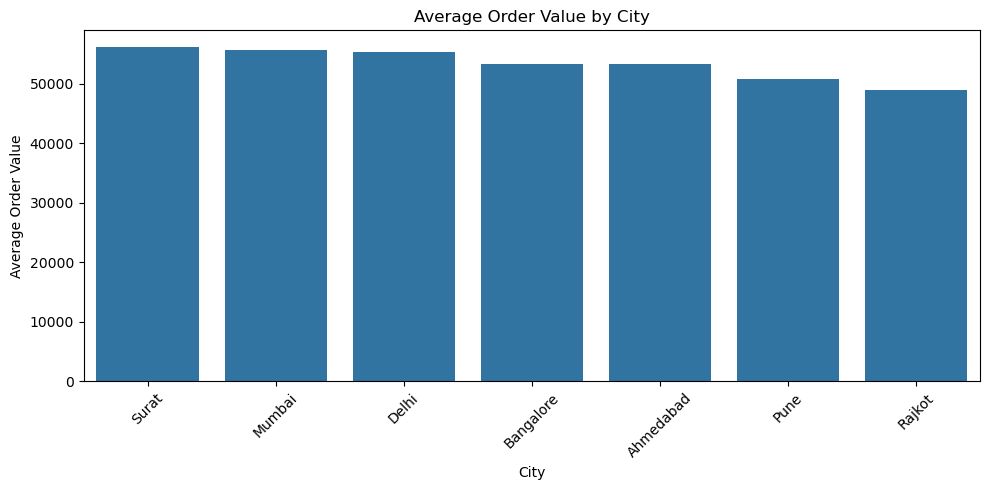

In [35]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=city_perf,
    x="city",
    y="avg_order_value"
)

plt.title("Average Order Value by City")
plt.xlabel("City")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/figures/city_avg_order_value.png", dpi=300)
plt.show()

In [36]:
# ltv
df_ltv = (
    order_items
    .merge(orders, on="order_id", how="inner")
    .merge(users, on="user_id", how="inner")
)

df_ltv = df_ltv[df_ltv["order_status"] == "DELIVERED"]

df_ltv["revenue"] = df_ltv["quantity"] * df_ltv["item_price"]

In [37]:
df_ltv[["user_id", "full_name", "order_id", "revenue"]].head()

,user_id,full_name,order_id,revenue
2,2,Prem Verma,2,22692.86
3,2,Prem Verma,3,23647.35
4,2,Prem Verma,3,55292.07
5,2,Prem Verma,3,58037.23
6,3,Rahul Malhotra,4,1493.28


In [38]:
customer_ltv = (
    df_ltv
    .groupby(["user_id", "full_name"], as_index=False)
    .agg(
        lifetime_value=("revenue", "sum"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("lifetime_value", ascending=False)
)

customer_ltv.head(10)

,user_id,full_name,lifetime_value,total_orders
137,144,Priya Singh,867728.79,8
702,736,Amit Malhotra,866467.80,10
690,724,Nikita Singh,843337.23,10
709,743,Rohit Singh,797860.73,10
317,332,Amit Desai,788299.81,8
382,400,Priya Singh,729078.27,9
82,89,Kaushik Iyer,654026.97,10
449,470,Neha Gupta,648251.23,9
653,686,Karan Joshi,644084.97,10
377,395,Kerav Desai,625185.20,9


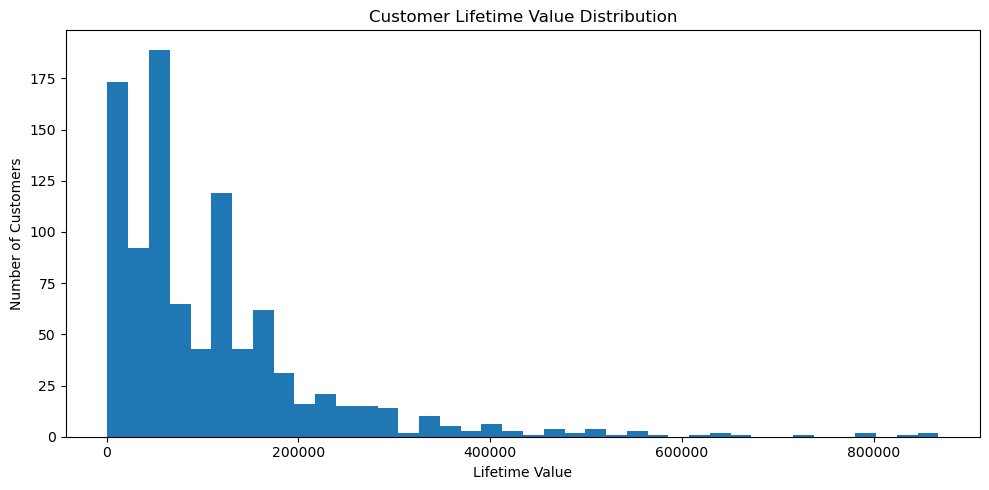

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_ltv["lifetime_value"],
    bins=40
)

plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Lifetime Value")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig("../outputs/figures/customer_ltv_distribution.png", dpi=300)
plt.show()

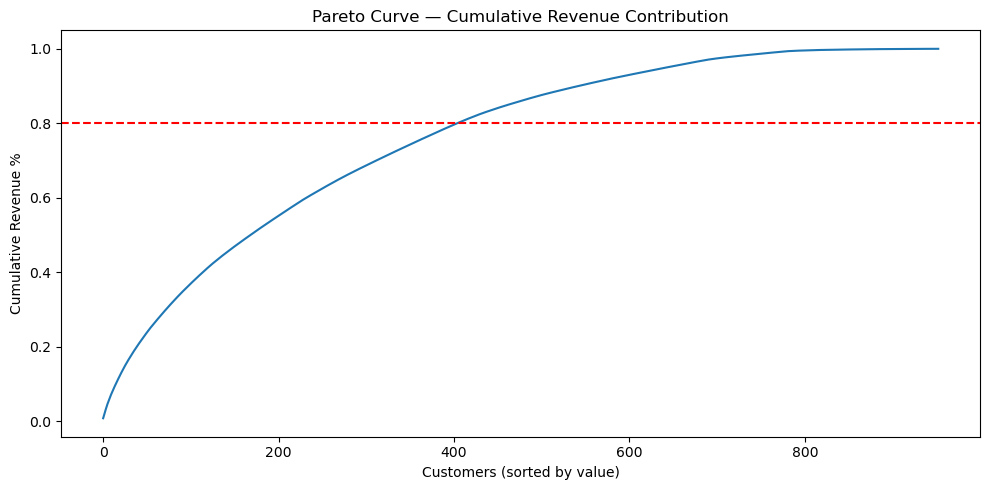

In [40]:
ltv_sorted = customer_ltv.sort_values(
    "lifetime_value", ascending=False
)

ltv_sorted["cum_revenue"] = ltv_sorted["lifetime_value"].cumsum()
ltv_sorted["cum_revenue_pct"] = (
    ltv_sorted["cum_revenue"] / ltv_sorted["lifetime_value"].sum()
)

plt.figure(figsize=(10, 5))
plt.plot(ltv_sorted["cum_revenue_pct"].values)
plt.axhline(0.8, color="red", linestyle="--")

plt.title("Pareto Curve — Cumulative Revenue Contribution")
plt.xlabel("Customers (sorted by value)")
plt.ylabel("Cumulative Revenue %")
plt.tight_layout()

plt.savefig("../outputs/figures/pareto_curve.png", dpi=300)
plt.show()

In [41]:
# payment
df_pay = (
    payments
    .merge(orders, on="order_id", how="inner")
    .merge(order_items, on="order_id", how="inner")
)

In [42]:
df_pay["revenue"] = df_pay["quantity"] * df_pay["item_price"]

In [43]:
failed_payments = df_pay[df_pay["payment_status"] == "FAILED"]

In [44]:
failed_payments[["payment_method", "order_id", "revenue"]].head()

,payment_method,order_id,revenue
82,UPI,54,45908.62
83,UPI,54,8971.26
97,CARD,66,1713.24
114,UPI,79,8302.54
115,UPI,79,2224.68


In [45]:
payment_failure_summary = (
    failed_payments
    .groupby("payment_method", as_index=False)
    .agg(
        failed_transactions=("order_id", "nunique"),
        potential_revenue_loss=("revenue", "sum")
    )
    .sort_values("potential_revenue_loss", ascending=False)
)

payment_failure_summary

,payment_method,failed_transactions,potential_revenue_loss
0,CARD,37,2038327.96
2,UPI,30,1481814.03
1,NETBANKING,20,1185600.19


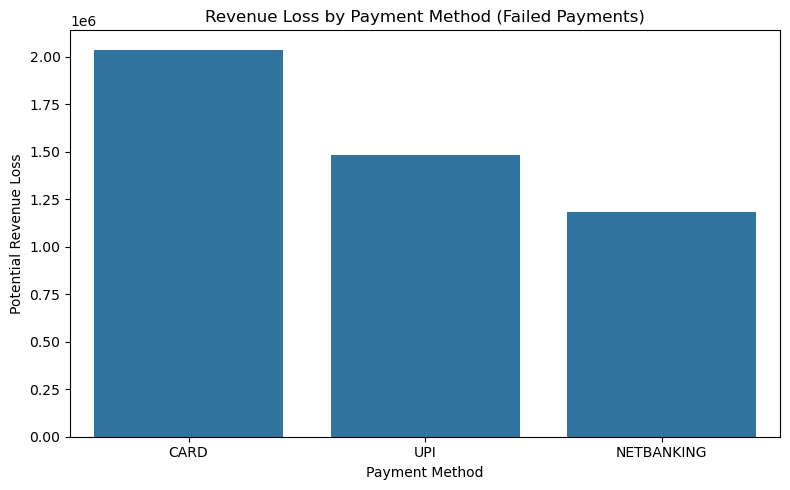

In [46]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=payment_failure_summary,
    x="payment_method",
    y="potential_revenue_loss"
)

plt.title("Revenue Loss by Payment Method (Failed Payments)")
plt.xlabel("Payment Method")
plt.ylabel("Potential Revenue Loss")
plt.tight_layout()

plt.savefig("../outputs/figures/payment_failure_revenue_loss.png", dpi=300)
plt.show()